## Propensity Modeling

##### Intro blurb about importance of understanding what are the drivers for respondents to seek treatment
> ##### Represented in the data by treatment_enc
##### Logistic Regression will provide a baseline read on drivers
##### Elastic Net Regression will be used to identify the most predictive variables, while reducing noise from redundant variables
##### Decision Tree Model will be used for interpretable rules
##### PC/UMAP and Clusters will be leveraged for interpretation

### Load relevant libraries

In [4]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score

### Read in the Data

In [5]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/OSMH/Data'
os.chdir(path)

In [6]:
df = pd.read_csv('clustered_data.csv')

### Define Model

##### Modeling will omit demographic and categorical variables
##### Focus will be on workplace and personal risk variables to understand what drives treatment, as opposed to who seeks treatment

In [7]:
df_model = df.copy()

feature_cols = [
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5',
    'UMAP1', 'UMAP2',
    'cluster',
    'support_score', 'wellness_program_enc', 'care_options_enc'
]

X = df_model[feature_cols]

# Get dummies for cluster labels
X = pd.get_dummies(X, columns=['cluster'], drop_first=True)

y=df_model['treatment_enc']

# Normalize continuous features
continuous_cols = ['PC1','PC2','PC3','PC4','PC5','UMAP1','UMAP2','support_score']
scaler = StandardScaler()
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

In [8]:
### Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Logistic Regression

In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_prob = log_reg.predict_proba(X_test)[:,1]
y_pred = log_reg.predict(X_test)

print("Baseline Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_prob))
print("Brier score:", brier_score_loss(y_test, y_pred_prob))
print("Feature coefficients:\n", pd.Series(log_reg.coef_[0], index=X.columns))

Baseline Logistic Regression
Accuracy: 0.6762820512820513
AUC-ROC: 0.7234384691369369
Brier score: 0.2127015997955135
Feature coefficients:
 PC1                     0.598085
PC2                     0.433208
PC3                     0.188818
PC4                     0.764975
PC5                     0.218340
UMAP1                  -0.058768
UMAP2                   0.072433
support_score           0.654679
wellness_program_enc   -0.324784
care_options_enc       -0.297776
cluster_1              -0.660075
cluster_2              -0.710696
dtype: float64


##### Strong positive predictors
> ##### PC4, dominant latent factor
> ##### support_score, perceived support matters
> ##### PC1, PC2 broader latent structure
##### Negative predictors are counterintuitive, but consistent
> ##### wellness_program, care_options
> ##### suggests that Availability != perceived safety or usability
##### Cluster group means showed that cluster 0 had the highest treatment score
> ##### Cluster 1 and 2 having negative coefficients makes sense

### Elastic Net Regression

##### Regularization adds a penalty to the model to prevent overfitting and control complexity
> ##### This highlights signal vs noise
##### Elastic Net combines Lasso and Ridge regression
> ##### Lasso drives weak coefficients to 0, acting like automatic feature selection
>> ##### Simplifies models, drops irrelevant variables
> ##### Ridge shrinks coefficients to 0, while keeping all variables
>> ##### Handles multicollinearity
#####
##### The survey variables have several correlated variables, and PCA components are derived from them
##### Elastic Net allows groups of correlated variables to be selected together, while also stabilizing coefficients and performing feature selection

In [10]:
log_reg_cv = LogisticRegressionCV(
    Cs=10,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.5],
    cv=5,
    max_iter=2000,
    random_state=42
)
log_reg_cv.fit(X_train, y_train)

y_pred_prob_en = log_reg_cv.predict_proba(X_test)[:, 1]
y_pred_en = log_reg_cv.predict(X_test)

print("\nElastic Net Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_en))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_prob_en))
print("Brier score:", brier_score_loss(y_test, y_pred_prob_en))
print("Feature coefficients:\n", pd.Series(log_reg_cv.coef_[0], index=X.columns))


Elastic Net Logistic Regression
Accuracy: 0.6784188034188035
AUC-ROC: 0.7234109025751763
Brier score: 0.21265459198540076
Feature coefficients:
 PC1                     0.611629
PC2                     0.446728
PC3                     0.189814
PC4                     0.764198
PC5                     0.222716
UMAP1                  -0.056539
UMAP2                   0.073886
support_score           0.656875
wellness_program_enc   -0.323028
care_options_enc       -0.299108
cluster_1              -0.745238
cluster_2              -0.772443
dtype: float64


##### Regularization didn't improve predictive performance
> ##### Accuracy, AUC-ROC, and Brier scores are all similar between Logistic and Elastic Net
> ##### Suggests baseline model didn't have major overfitting and feature space isn't excessively noisy
##### Coefficients are nearly identical across models
> ##### No unstable/redundant signal being 'corrected' by regularization
##### Clusters showed a stronger (negative) effect

### Decision Tree Classifier

In [11]:
### Reason for why using Elastic Net

In [12]:
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_train, y_train)

y_pred_prob_tree = dtree.predict_proba(X_test)[:,1]
print('\nDecision Tree')
print('Accuracy:', accuracy_score(y_test, dtree.predict(X_test)))
print('AUC-ROC:', roc_auc_score(y_test, y_pred_prob_tree))


Decision Tree
Accuracy: 0.657051282051282
AUC-ROC: 0.6922606877857159


##### Decision Tree performs worse than logistic regressions
> ##### Data has a strong linear signal, which trees approximate less efficiently
##### Suggests treatment-seeking behavior is driven more by continuous latent factors than by sharp decision boundaries
##### Reveals interpretale decision paths and conditional relationships between features

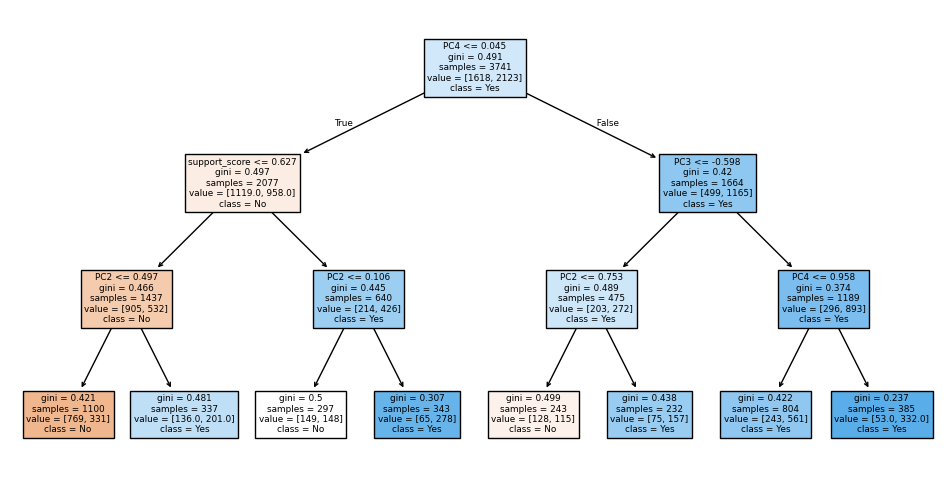

In [13]:
plt.figure(figsize=(12,6))
plot_tree(dtree, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.show()

##### PC4 is primary driver of treatment behavior in decision tree
> ##### Coincides with logistic regression results
##### High PC4 (>0.05) show consistently high likelihood of seeking treatment (Class = Yes)
> ##### PC3 and PC2 further refine results
##### For those with lower PC4, behavior becomes conditional on both workplace support (support_score) and secondary latent traits (PC2)

### Segmenting based on results

##### Segment 1: High latent risk / need
> ##### PC4 high
> ##### High probability of treatment
##### Individuals strongly predisposed toward treatment, largely independent of workplace conditions

##### Segment 2: Low risk / high support
> ##### PC4 low, support high
> ##### Outcome depends on PC2
##### Individuals where support exists, but treatment still depends on personal/latent factors

##### Segment 3: Low risk / low support
> ##### PC4 low, support low
> ##### Outcome depends on PC2
##### Individuals where both structural support and latent traits jointly influence treatment decisions

### Do segments align with clusters?

In [14]:
df.groupby('cluster')[['PC4','PC2']].mean()

,PC4,PC2
cluster,,
0,0.532890,-2.397599
1,0.438252,-0.639859
2,-0.175317,0.520618


##### Clusters 0 and 1 are more aligned with PC4, the 'treatment-seeking' latent factor
##### Cluster 2 is less so

In [15]:
df.groupby('cluster')['PC4'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,560.0,0.532890,1.802213,-2.944325,-0.633337,0.336892,1.763852,5.364269
1,690.0,0.438252,0.756387,-2.733939,-0.003938,0.519506,1.042950,2.131962
2,3427.0,-0.175317,0.961225,-3.170681,-0.873844,-0.287080,0.456006,3.177888


In [16]:
df['pc4_segment'] = np.where(df['PC4'] > 0.05, 'High_PC4', 'Low_PC4')

In [17]:
pd.crosstab(df['cluster'], df['pc4_segment'], normalize='index')

pc4_segment,High_PC4,Low_PC4
cluster,,
0,0.573214,0.426786
1,0.620290,0.379710
2,0.384593,0.615407


##### Cluster 1 has the most 'High_PC4' respondents
##### Cluster 0 also majority high PC4
##### Cluster 2 mostly low PC4

In [18]:
df.groupby(['cluster', 'pc4_segment'])['treatment_enc'].mean()

cluster  pc4_segment
0        High_PC4       0.682243
         Low_PC4        0.322176
1        High_PC4       0.705607
         Low_PC4        0.324427
2        High_PC4       0.694234
         Low_PC4        0.488383
Name: treatment_enc, dtype: float64

##### Results within clusters also confirm that High_PC4 segments are more likely to seek treatment
> ##### High PC4 = ~70% treatment across all clusters
##### PC4 is a universal driver of treatment-seeking, independent of cluster membership

##### Clusters primarily differentiate behavior among individuals who aren't already predisposed toward treatment (low PC4)
> ##### Clusters 0 & 1 show low (~32%) treatment when PC4 is low
> ##### Cluster 2 (~0.49%) have much higher baseline treatment

##### Cluster 1: High latent need, awareness-constrained
> ##### Highest % of High_PC4
> ##### Highest treatment when predisposed
> ##### Low_PC4 group still shows low treatment (~32%)
##### High need, but behavior still depends on awareness/latent traits

##### Cluster 0: Moderate need, structurally constrained
> ##### Similar to Cluster 1 in behavior
> ##### Slightly lower PC4 concentration
##### Moderate latent need, but low baseine treatment when not strongly driven

##### Cluster 2: Lower latent need, but structurally enabling
> ##### Lowest PC4
> ##### Highest treatment among low PC4 group
##### Enables treatment even among individuals without strong intrinsic drivers

### Summary of Results

##### Latent factors (PC4) are the primary drivers of treatment-seeking behavior across all individuals
##### Cluster membership meaningfully differentiates behavior among those with lower intrinsic predisposition
##### Cluster 2 exhibits significantly higher treatment rates, even among low-PC4 individuals
> ##### Suggests that structural or environmental factors may lower barriers to care

#### Needs drive action, environment shapes accessibility

### Decoding PC4

In [19]:
pc4_loadings = pd.read_csv('PC4_loadings.csv').rename(columns={'Unnamed: 0':'Feature'})

In [20]:
pc4_loadings

,Feature,PC4_Loading
0,leave_enc,0.574211
1,work_interfere_enc,0.487234
2,obs_consequence_enc,0.373320
3,family_history_enc,0.371609
4,self_employed_enc,0.224525
5,care_options_enc,0.208816
6,mental_vs_physical_enc,-0.167101
7,support_score,-0.128796
8,tech_company_enc,-0.079756
9,benefits_enc,-0.072721


##### Strong positive drivers
> ##### Comfort taking leave for mental health
> ##### Whether mental health impacts work
> ##### Observed workplace consequences
> ##### Family history

##### Weak negative drivers
> ##### Support score, employer-provided benefits, employer-provided informational resources

#### PC4 isn't about workplace support, it's about personal experience, perceived impact, and behavioral readiness

### How PC4 ties back to Cluster 2

##### Cluster 2 showed high treatment among low PC4 individuals
> ##### Higher treatment among those least likely to recognize or act on mental health needs

##### Cluster 2 showed:
> ##### Moderate support score
> ##### Higher benefits
> ##### Moderate care options
> ##### Fewer 'I don't know' responses than Cluster 1

##### A supportive environment nudges individuals who aren't predisposed into treatment anyway

#### Supportive environments can compensate for low mental health salience by lowering the effort required to seek treatment

### Unified Framework

##### Axis 1: Personal readiness (PC4)
> ##### Do I feel this matters?
> ##### Am I ready to act?
##### Axis 2: Environment (Clusters)
> ##### Can I act easily?
> ##### Do I understand how?

In [21]:
### Derive environment score for Axis 2 from PC4 loadings and Cluster interpretations
# Meant to be a composite score that reflects workplace-provided resources and clarity around treatment options
df['environment_score'] = df[['support_score', 'care_options_enc', 'benefits_enc']].mean(axis=1)

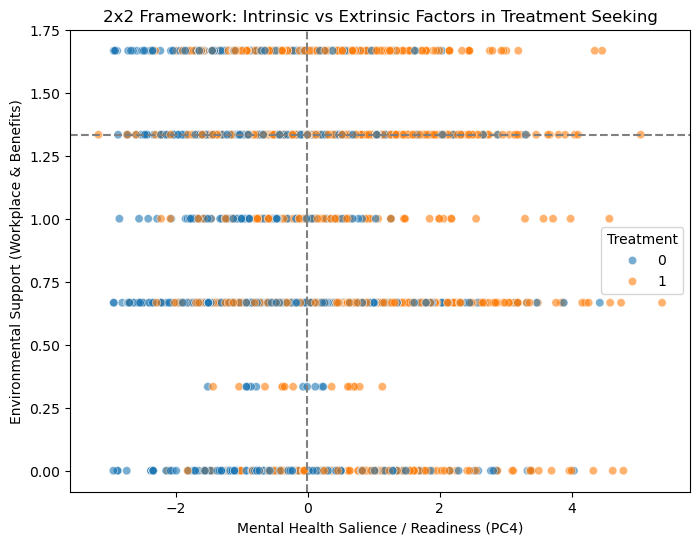

In [22]:
### Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC4',
    y='environment_score',
    hue='treatment_enc',
    data=df,
    alpha=0.6
)

plt.axvline(df['PC4'].median(), color='gray', linestyle='--')
plt.axhline(df['environment_score'].median(), color='gray', linestyle='--')

plt.xlabel('Mental Health Salience / Readiness (PC4)')
plt.ylabel('Environmental Support (Workplace & Benefits)')
plt.title('2x2 Framework: Intrinsic vs Extrinsic Factors in Treatment Seeking')
plt.legend(title='Treatment')
plt.show()

##### Interpreting the Framework Chart
> ##### X-axis: PC4 - mental health salience / readiness
> ##### Y-axis: Environment Score - workplace support
>> ##### Derived from discrete workplace benefits and policies, resulting in horizontal striping
> ##### Color: Treatment (1 = Yes, 0 = No)
> ##### Dashed Lines: Median Splits

##### Quadrant Analysis
##### Bottom-left: Low PC4, Low Support
> ##### Mostly blue, lowest treatment rates
> ##### Individuals neither feel strong need nor have strong support
##### Bottom-right: High PC4, Low Support
> ##### Mixed treatment results, but more orange
> ##### Individuals seek treatment when they feel they need it, even without support
>> ##### Intrinsic motivation can overcome structural barriers
> ##### This represents Cluster 1 conceptually
##### Top-left: Low PC4, High Support
> ##### More orange than Bottom-Left
> ##### Supportive environments increase treatment, even without strong personal readiness
> ##### This represents Cluster 2 conceptually
##### Top-right: High PC4, High Support
> ##### Most orange, highest treatment rates

#### Environment moderates the effect of PC4
> ##### When readiness is high, environment matters less
> ##### When readiness is low, environment matters a lot